Epoch 0: D Loss: 1.3821, G Loss: 0.7446
Epoch 100: D Loss: 1.1944, G Loss: 0.8948
Epoch 200: D Loss: 0.9728, G Loss: 1.0060
Epoch 300: D Loss: 1.5889, G Loss: 0.7008
Epoch 400: D Loss: 1.1603, G Loss: 1.1272
Epoch 500: D Loss: 1.3157, G Loss: 0.8380
Epoch 600: D Loss: 1.6122, G Loss: 0.4549
Epoch 700: D Loss: 1.3454, G Loss: 1.0529
Epoch 800: D Loss: 0.9094, G Loss: 1.0594
Epoch 900: D Loss: 1.5425, G Loss: 0.7603
Epoch 1000: D Loss: 0.9064, G Loss: 1.0559
Epoch 1100: D Loss: 0.7316, G Loss: 1.4166
Epoch 1200: D Loss: 1.3119, G Loss: 0.7557
Epoch 1300: D Loss: 1.0328, G Loss: 1.3245
Epoch 1400: D Loss: 1.2014, G Loss: 0.9161
Epoch 1500: D Loss: 1.1841, G Loss: 0.9604
Epoch 1600: D Loss: 1.2884, G Loss: 0.6915
Epoch 1700: D Loss: 0.7026, G Loss: 1.3690
Epoch 1800: D Loss: 0.9314, G Loss: 1.2484
Epoch 1900: D Loss: 0.7495, G Loss: 1.2689
Epoch 2000: D Loss: 0.8285, G Loss: 1.3510
Epoch 2100: D Loss: 0.5847, G Loss: 1.6709
Epoch 2200: D Loss: 1.5088, G Loss: 0.4310
Epoch 2300: D Loss: 0.9

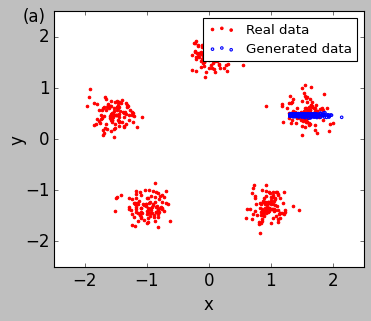

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats

# 设置随机数种子
seed = 74###########连续5次随机种子看看是否成功
torch.manual_seed(seed) #设置Pytorch的随机种子
np.random.seed(seed) #设置Numpy的随机种子

def genGauss(p, n=1, r=1): #生成高斯分布的随机数据，并进行一定的预处理，返回一个归一化的训练数据集，便于进一步分析或建模。
    x = []
    y = []
    for k in range(n):#使用for循环从0到n-1进行迭代，每次迭代生成一组高斯分布的点
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)
    #np.random.multivariate_normal 函数用来生成多元正态分布的数据。
    #第一参数是均值 [math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)]，表示每组数据的中心点
    #第二参数是协方差矩阵 [[0.0125, 0], [0, 0.0125]]，表示数据的分散程度。
    #第三参数 p 是需要生成的样本数量。.T 是对生成的数据进行转置，便于后续处理。
    
    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input): #定义前向传播方法，该方法在输入数据通过模型时被调用
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()#定义 ReLU 激活函数的实例 relu，在每个全连接层后将会使用。
        self.sigmoid = nn.Sigmoid()#定义 Sigmoid 激活函数的实例 sigmoid，用于输出层。

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

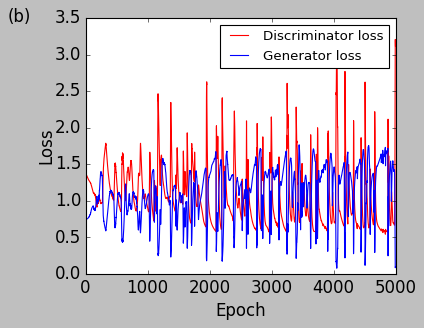

In [3]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

Evaluating GAN performance...

1. Distribution Comparison:


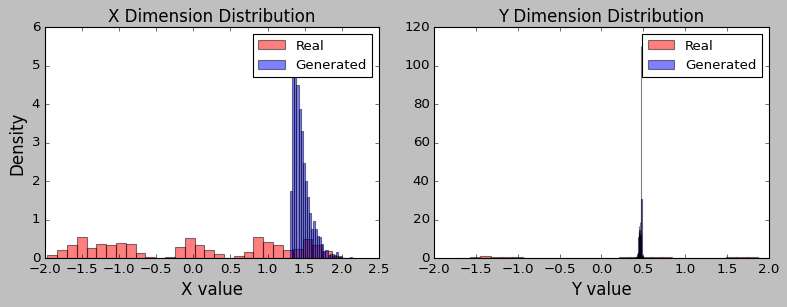

  Wasserstein distance (X-dim): 1.4593
  Wasserstein distance (Y-dim): 0.9986

2. Gradient Convergence Analysis:


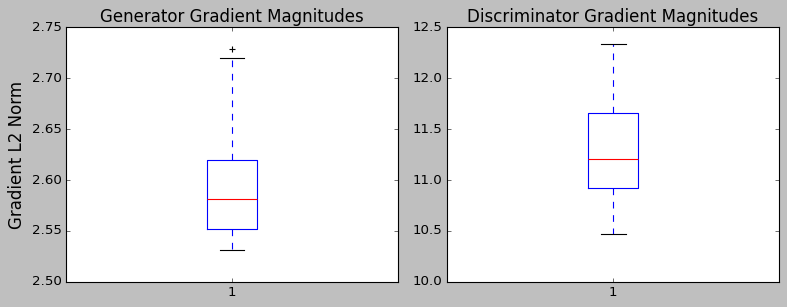

  Generator gradient mean: 2.5943
  Discriminator gradient mean: 11.3032

3. Coverage Metrics:


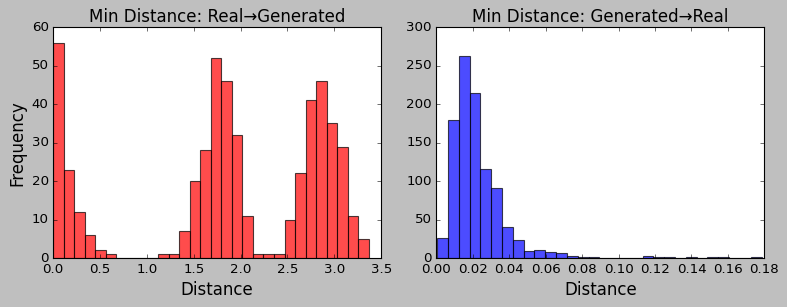

  Precision (Gen→Real): 0.0225
  Recall (Real→Gen): 1.8860

4. Density Estimation:


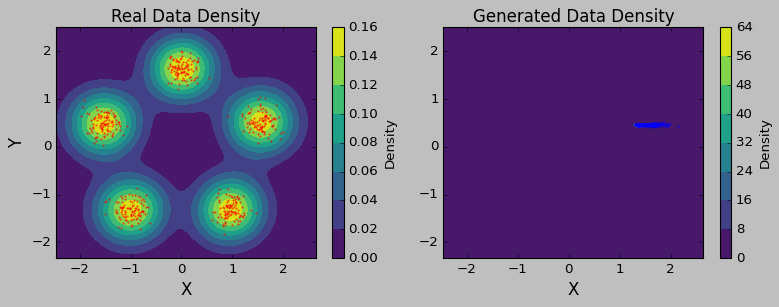

  JS Divergence: 0.6734

5. Mode Coverage Analysis:


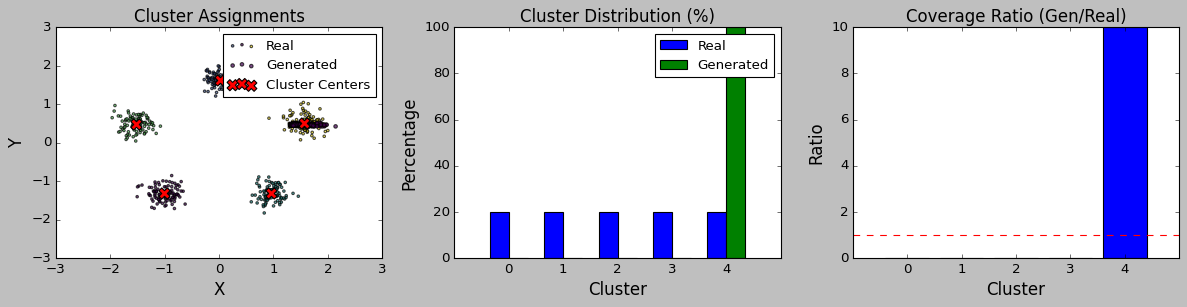

  Mode collapse score: 32.0000
  Average coverage ratio: 2.0000


In [24]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()

#一.分布比较可视化
#绘制X_train和samples数据X轴和Y轴分布直方图
def plot_distribution_comparison(real_data, generated_data):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.rcParams['font.serif'] = ['Times New Roman']
    mpl.rcParams['figure.dpi'] = 800
    mpl.rcParams['axes.unicode_minus'] = False
    plt.style.use(['classic'])
    # X轴分布直方图
    axes[0].hist(real_data[:, 0], bins=30, alpha=0.5, density=True, color='red', label='Real')
    axes[0].hist(generated_data[:, 0], bins=30, alpha=0.5, density=True, color='blue', label='Generated')
    axes[0].set_title('X Dimension Distribution', fontsize=15)
    axes[0].legend(fontsize=12)
    axes[0].set_xlabel('X value', fontsize=15)
    axes[0].set_ylabel('Density', fontsize=15)
    axes[0].tick_params(labelsize=12)
    # Y轴分布直方图
    axes[1].hist(real_data[:, 1], bins=30, alpha=0.5, density=True, color='red', label='Real')
    axes[1].hist(generated_data[:, 1], bins=30, alpha=0.5, density=True, color='blue', label='Generated')
    axes[1].set_title('Y Dimension Distribution', fontsize=15)
    axes[1].legend(fontsize=12)
    axes[1].set_xlabel('Y value', fontsize=15)
    axes[1].tick_params(labelsize=12)
    
    plt.tight_layout()
#   plt.savefig('D:/GAN2024/distribution_comparison.eps', dpi=800)
    plt.show()
    
    # Return Wasserstein distances for each dimension
    w_dist_x = wasserstein_distance(X_train_np[:, 0], samples[:, 0])
    w_dist_y = wasserstein_distance(X_train_np[:, 1], samples[:, 1])
    return w_dist_x, w_dist_y

#二.梯度幅度可视化
#可视化生成器和判别器在训练过程中梯度的变化，并返回梯度的统计信息.
def plot_gradient_convergence(generator, discriminator, X_train, z_dim, batch_size=32, num_samples=20):
    # Set up the figure
    plt.rcParams['font.serif'] = ['Times New Roman']
    mpl.rcParams['figure.dpi'] = 800
    mpl.rcParams['axes.unicode_minus'] = False
    plt.style.use(['classic'])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Track gradient norms over multiple mini-batches
    g_grad_norms = []
    d_grad_norms = []
    for _ in range(num_samples):
        # Sample random batch 获取一个随机小批量样本
        indices = torch.randperm(X_train.size(0))[:batch_size]
        image_batch = X_train[indices]
        # Generate fake images 生成假图像
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)
        # Compute discriminator gradients 计算判别器梯度
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())
        d_loss = -torch.mean(torch.log(d_real + 1e-8)) - torch.mean(torch.log(1 - d_fake + 1e-8))
        # Zero gradients and backward pass for discriminator 清零梯度并计算判别器的反向传播
        for param in discriminator.parameters():
            if param.grad is not None:
                param.grad.zero_()
        d_loss.backward()
        # Compute and store discriminator gradient norms 计算并存储判别器的梯度L2范数
        d_grad_norm = 0
        for param in discriminator.parameters():
            if param.grad is not None:
                d_grad_norm += param.grad.norm().item() ** 2
        d_grad_norms.append(np.sqrt(d_grad_norm))
        # Compute generator gradients 计算生成器梯度
        d_fake, _ = discriminator(fake_img)
        g_loss = -torch.mean(torch.log(d_fake + 1e-8))
        # Zero gradients and backward pass for generator 清零梯度并计算生成器的反向传播
        for param in generator.parameters():
            if param.grad is not None:
                param.grad.zero_()
        g_loss.backward()
        # Compute and store generator gradient norms 计算并存储生成器的梯度L2范数
        g_grad_norm = 0
        for param in generator.parameters():
            if param.grad is not None:
                g_grad_norm += param.grad.norm().item() ** 2
        g_grad_norms.append(np.sqrt(g_grad_norm))
    # Plot the gradient norms 绘制梯度幅度箱线图
    axes[0].boxplot(g_grad_norms)
    axes[0].set_title('Generator Gradient Magnitudes', fontsize=15)
    axes[0].set_ylabel('Gradient L2 Norm', fontsize=15)
    axes[0].tick_params(labelsize=12)
    axes[1].boxplot(d_grad_norms)
    axes[1].set_title('Discriminator Gradient Magnitudes', fontsize=15)
    axes[1].tick_params(labelsize=12)
    
    plt.tight_layout()
#    plt.savefig('D:/GAN2024/gradient_magnitudes.eps', dpi=800)
    plt.show()
    
    # Return statistics about gradients 返回梯度统计信息
    return {
        'generator_grad_mean': np.mean(g_grad_norms),
        'generator_grad_std': np.std(g_grad_norms),
        'discriminator_grad_mean': np.mean(d_grad_norms),
        'discriminator_grad_std': np.std(d_grad_norms)
    }

#三.最小距离分布(覆盖范围和模式崩溃检测)
#计算生成数据和真实数据之间的覆盖度指标，并通过可视化的方式展示生成数据和真实数据之间的距离关系
def plot_coverage_metrics(real_data, generated_data):
    plt.rcParams['font.serif'] = ['Times New Roman']
    mpl.rcParams['figure.dpi'] = 800
    mpl.rcParams['axes.unicode_minus'] = False
    plt.style.use(['classic'])
    # Compute minimum distances from real to generated 计算从真实数据到生成数据的最小距离
    real_to_gen_distances = pairwise_distances(real_data, generated_data)
    min_real_to_gen = np.min(real_to_gen_distances, axis=1)
    # Compute minimum distances from generated to real 计算从生成数据到真实数据的最小距离
    gen_to_real_distances = pairwise_distances(generated_data, real_data)
    min_gen_to_real = np.min(gen_to_real_distances, axis=1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Plot histograms of minimum distances 绘制从真实数据到生成数据的最小距离的直方图
    axes[0].hist(min_real_to_gen, bins=30, color='red', alpha=0.7)
    axes[0].set_title('Min Distance: Real→Generated', fontsize=15)
    axes[0].set_xlabel('Distance', fontsize=15)
    axes[0].set_ylabel('Frequency', fontsize=15)
    axes[0].tick_params(labelsize=12)
    # 绘制从生成数据到真实数据的最小距离的直方图
    axes[1].hist(min_gen_to_real, bins=30, color='blue', alpha=0.7)
    axes[1].set_title('Min Distance: Generated→Real', fontsize=15)
    axes[1].set_xlabel('Distance', fontsize=15)
    axes[1].tick_params(labelsize=12)
    
    plt.tight_layout()
#    plt.savefig('D:/GAN2024/coverage_metrics.eps', dpi=800)
    plt.show()
    
    # Return coverage and quality metrics 计算并返回覆盖度和质量指标
    metrics = {
        'precision': np.mean(min_gen_to_real),  # Lower is better (generated points close to real data)
        'recall': np.mean(min_real_to_gen),     # Lower is better (real points covered by generated)
        'precision_std': np.std(min_gen_to_real),
        'recall_std': np.std(min_real_to_gen)
    }
    return metrics

#四.核密度可视化
#通过绘制真实数据和生成数据的核密度估计热图来比较这两者的分布，并计算它们之间的JS散度
def plot_density_heatmap(real_data, generated_data):
    plt.rcParams['font.serif'] = ['Times New Roman']
    mpl.rcParams['figure.dpi'] = 800
    mpl.rcParams['axes.unicode_minus'] = False
    plt.style.use(['classic'])
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    # Define the grid
    x_min, x_max = min(real_data[:, 0].min(), generated_data[:, 0].min()) - 0.5, max(real_data[:, 0].max(), generated_data[:, 0].max()) + 0.5
    y_min, y_max = min(real_data[:, 1].min(), generated_data[:, 1].min()) - 0.5, max(real_data[:, 1].max(), generated_data[:, 1].max()) + 0.5
    
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    # Compute KDE for real data 计算真实数据的KDE
    real_kernel = stats.gaussian_kde(real_data.T)
    real_density = np.reshape(real_kernel(positions), xx.shape)
    # Compute KDE for generated data 计算生成数据的KDE
    gen_kernel = stats.gaussian_kde(generated_data.T)
    gen_density = np.reshape(gen_kernel(positions), xx.shape)
    # Plot real data KDE 绘制真实数据的KDE热图
    im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
    axes[0].set_title('Real Data Density', fontsize=15)
    axes[0].set_xlabel('X', fontsize=15)
    axes[0].set_ylabel('Y', fontsize=15)
    axes[0].scatter(real_data[:, 0], real_data[:, 1], s=1, color='red', alpha=0.5)
    axes[0].tick_params(labelsize=12)
    # Plot generated data KDE 绘制生成数据的KDE热图
    im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
    axes[1].set_title('Generated Data Density', fontsize=15)
    axes[1].set_xlabel('X', fontsize=15)
    axes[1].scatter(generated_data[:, 0], generated_data[:, 1], s=1, color='blue', alpha=0.5)
    axes[1].tick_params(labelsize=12)
    
    fig.colorbar(im1, ax=axes[0], label='Density')
    fig.colorbar(im2, ax=axes[1], label='Density')
    
    plt.tight_layout()
#    plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
    plt.show()
    
    # JS divergence between the two distributions (approximate) 计算JS散度
    js_divergence = js_divergence_approx(real_density, gen_density)
    return js_divergence

# Helper function to approximate JS divergence
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js

#五.模式覆盖可视化
#计算GAN中生成数据和真实数据在不同聚类中的覆盖率，并绘制相关的可视化图像。
#首先使用KMeans聚类算法对真实数据进行聚类，然后计算生成数据和真实数据的覆盖情况，最后绘制了多种图表来展示结果
def plot_mode_coverage(real_data, generated_data, n_clusters=5):
    from sklearn.cluster import KMeans
    
    plt.rcParams['font.serif'] = ['Times New Roman']
    mpl.rcParams['figure.dpi'] = 800
    mpl.rcParams['axes.unicode_minus'] = False
    plt.style.use(['classic'])
    # Fit KMeans to real data to identify modes 使用KMeans对真实数据进行聚类
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    real_clusters = kmeans.fit_predict(real_data)
    centers = kmeans.cluster_centers_
    # Assign generated data to the same clusters 将生成数据分配到相同的聚类
    gen_clusters = kmeans.predict(generated_data)
    # Count points in each cluster 统计每个聚类中的点数
    real_counts = np.bincount(real_clusters, minlength=n_clusters)
    gen_counts = np.bincount(gen_clusters, minlength=n_clusters)
    # Normalize to percentages 将点数转换为百分比
    real_percents = 100 * real_counts / len(real_data)
    gen_percents = 100 * gen_counts / len(generated_data)
    # Compute cluster coverage 计算覆盖率比率
    coverage_ratio = gen_counts / (real_counts + 1e-10)  # Add small constant to avoid division by zero
    # Plot the results
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    # Scatter plot with cluster assignments 绘制聚类分配的散点图
    axes[0].scatter(real_data[:, 0], real_data[:, 1], c=real_clusters, cmap='viridis', 
                   marker='.', alpha=0.7, label='Real')
    axes[0].scatter(generated_data[:, 0], generated_data[:, 1], c=gen_clusters, cmap='viridis', 
                   marker='o', facecolors='none', edgecolors='black', s=10, alpha=0.7, label='Generated')
    axes[0].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=100, label='Cluster Centers')
    axes[0].set_title('Cluster Assignments', fontsize=15)
    axes[0].set_xlabel('X', fontsize=15)
    axes[0].set_ylabel('Y', fontsize=15)
    axes[0].legend(fontsize=12)
    axes[0].tick_params(labelsize=12)
    # Bar chart of distribution 绘制聚类分布的柱状图
    width = 0.35
    x = np.arange(n_clusters)
    axes[1].bar(x - width/2, real_percents, width, label='Real')
    axes[1].bar(x + width/2, gen_percents, width, label='Generated')
    axes[1].set_title('Cluster Distribution (%)', fontsize=15)
    axes[1].set_xlabel('Cluster', fontsize=15)
    axes[1].set_ylabel('Percentage', fontsize=15)
    axes[1].set_xticks(x)
    axes[1].legend(fontsize=12)
    axes[1].tick_params(labelsize=12)
    # Coverage ratio 绘制覆盖率比率的柱状图
    axes[2].bar(x, coverage_ratio)
    axes[2].axhline(y=1.0, color='r', linestyle='--')
    axes[2].set_title('Coverage Ratio (Gen/Real)', fontsize=15)
    axes[2].set_xlabel('Cluster', fontsize=15)
    axes[2].set_ylabel('Ratio', fontsize=15)
    axes[2].set_xticks(x)
    axes[2].tick_params(labelsize=12)
    
    plt.tight_layout()
#    plt.savefig('D:/GAN2024/mode_coverage.eps', dpi=800)
    plt.show()
    
    # Calculate mode collapse score (lower is better, 0 = perfect match) 计算模式崩塌分数
    mode_collapse_score = np.mean(np.abs(real_percents - gen_percents))
    
    return {
        'mode_collapse_score': mode_collapse_score,
        'coverage_ratios': coverage_ratio,
        'avg_coverage_ratio': np.mean(coverage_ratio)
    }


# Run all evaluations
print("Evaluating GAN performance...")
    
print("\n1. Distribution Comparison:")
w_dist_x, w_dist_y = plot_distribution_comparison(X_train_np, samples)
print(f"  Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"  Wasserstein distance (Y-dim): {w_dist_y:.4f}")

print("\n2. Gradient Convergence Analysis:")
grad_metrics = plot_gradient_convergence(generator, discriminator, X_train, z_dim)
print(f"  Generator gradient mean: {grad_metrics['generator_grad_mean']:.4f}")
print(f"  Discriminator gradient mean: {grad_metrics['discriminator_grad_mean']:.4f}")

print("\n3. Coverage Metrics:")
coverage_metrics = plot_coverage_metrics(X_train_np, samples)
print(f"  Precision (Gen→Real): {coverage_metrics['precision']:.4f}")
print(f"  Recall (Real→Gen): {coverage_metrics['recall']:.4f}")

print("\n4. Density Estimation:")
js_div = plot_density_heatmap(X_train_np, samples)
print(f"  JS Divergence: {js_div:.4f}")

print("\n5. Mode Coverage Analysis:")
mode_metrics = plot_mode_coverage(X_train_np, samples, n_clusters=5)
print(f"  Mode collapse score: {mode_metrics['mode_collapse_score']:.4f}")
print(f"  Average coverage ratio: {mode_metrics['avg_coverage_ratio']:.4f}")

Wasserstein distance (X-dim): 1.4593
Wasserstein distance (Y-dim): 0.9986
JS Divergence: 0.6734


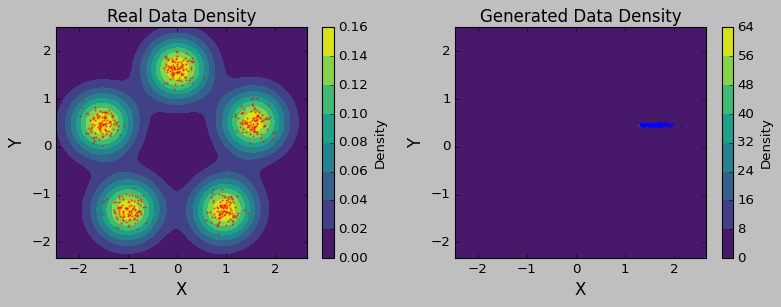

In [10]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

Epoch 0: D Loss: 1.4052, G Loss: 0.5775
Epoch 100: D Loss: 1.1398, G Loss: 0.7679
Epoch 200: D Loss: 0.9261, G Loss: 0.9477
Epoch 300: D Loss: 1.2485, G Loss: 0.9889
Epoch 400: D Loss: 1.4832, G Loss: 1.0177
Epoch 500: D Loss: 1.2025, G Loss: 0.8397
Epoch 600: D Loss: 1.2207, G Loss: 0.8507
Epoch 700: D Loss: 1.2620, G Loss: 0.9217
Epoch 800: D Loss: 1.2813, G Loss: 0.7719
Epoch 900: D Loss: 1.1100, G Loss: 1.0199
Epoch 1000: D Loss: 1.2688, G Loss: 0.7954
Epoch 1100: D Loss: 1.2234, G Loss: 0.8273
Epoch 1200: D Loss: 1.2914, G Loss: 0.8431
Epoch 1300: D Loss: 1.5276, G Loss: 0.4948
Epoch 1400: D Loss: 1.1683, G Loss: 0.9424
Epoch 1500: D Loss: 1.3736, G Loss: 0.6485
Epoch 1600: D Loss: 1.1957, G Loss: 0.9006
Epoch 1700: D Loss: 1.1144, G Loss: 0.9886
Epoch 1800: D Loss: 0.9414, G Loss: 1.1016
Epoch 1900: D Loss: 0.9419, G Loss: 1.1087
Epoch 2000: D Loss: 1.0925, G Loss: 1.0071
Epoch 2100: D Loss: 0.9511, G Loss: 1.0670
Epoch 2200: D Loss: 1.0317, G Loss: 1.0313
Epoch 2300: D Loss: 0.9

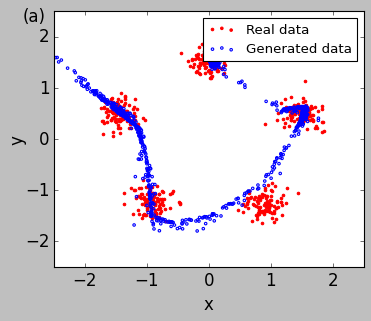

In [15]:
##第二次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
 
# 设置随机数种子
seed = 42###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

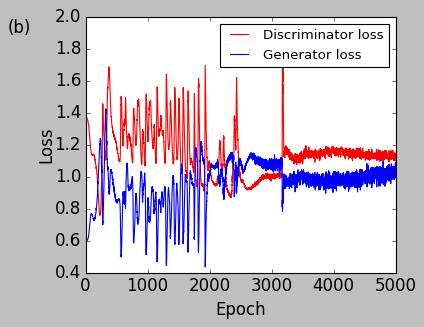

In [16]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.1870
Wasserstein distance (Y-dim): 0.5295
JS Divergence: 0.0684


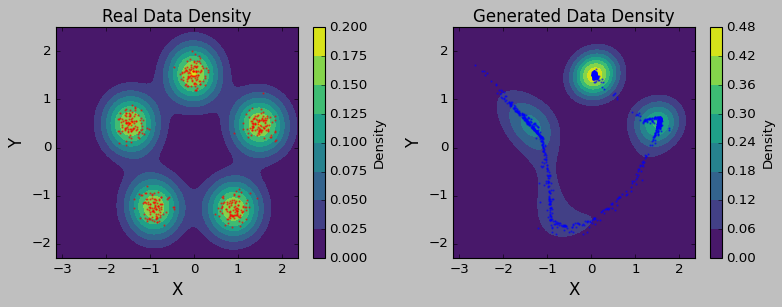

In [17]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

Epoch 0: D Loss: 1.4032, G Loss: 0.8447
Epoch 100: D Loss: 1.0748, G Loss: 0.9954
Epoch 200: D Loss: 1.2298, G Loss: 0.8358
Epoch 300: D Loss: 1.3034, G Loss: 0.6511
Epoch 400: D Loss: 1.0110, G Loss: 1.2022
Epoch 500: D Loss: 0.9326, G Loss: 1.2477
Epoch 600: D Loss: 2.1477, G Loss: 0.4718
Epoch 700: D Loss: 0.9870, G Loss: 1.0244
Epoch 800: D Loss: 1.4808, G Loss: 0.5710
Epoch 900: D Loss: 1.2298, G Loss: 1.2207
Epoch 1000: D Loss: 0.8038, G Loss: 1.0842
Epoch 1100: D Loss: 1.7369, G Loss: 0.5339
Epoch 1200: D Loss: 1.1627, G Loss: 0.7763
Epoch 1300: D Loss: 1.4028, G Loss: 0.8783
Epoch 1400: D Loss: 0.8978, G Loss: 1.1233
Epoch 1500: D Loss: 0.8570, G Loss: 1.1710
Epoch 1600: D Loss: 1.4240, G Loss: 1.0122
Epoch 1700: D Loss: 0.8461, G Loss: 1.2897
Epoch 1800: D Loss: 0.6610, G Loss: 1.4766
Epoch 1900: D Loss: 1.9775, G Loss: 0.7368
Epoch 2000: D Loss: 0.8602, G Loss: 1.2334
Epoch 2100: D Loss: 0.8860, G Loss: 0.9857
Epoch 2200: D Loss: 0.8990, G Loss: 1.0488
Epoch 2300: D Loss: 0.7

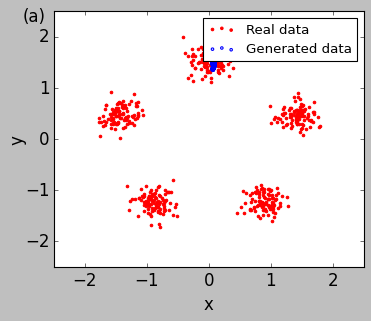

In [18]:
##第3次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
 
# 设置随机数种子
seed = 166###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

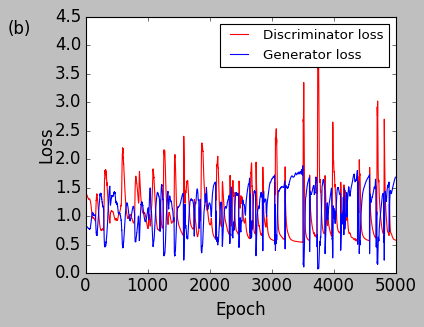

In [19]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.9445
Wasserstein distance (Y-dim): 1.4924
JS Divergence: 0.6743


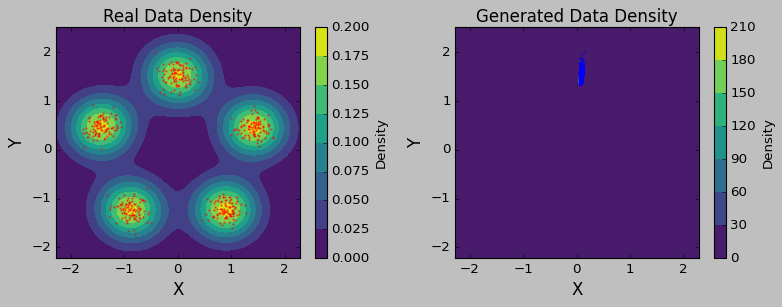

In [20]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

Epoch 0: D Loss: 1.4178, G Loss: 0.8871
Epoch 100: D Loss: 1.2780, G Loss: 0.8675
Epoch 200: D Loss: 1.0630, G Loss: 1.0511
Epoch 300: D Loss: 1.3211, G Loss: 0.8966
Epoch 400: D Loss: 1.1745, G Loss: 0.8920
Epoch 500: D Loss: 1.5625, G Loss: 0.6575
Epoch 600: D Loss: 1.2445, G Loss: 0.6845
Epoch 700: D Loss: 1.3271, G Loss: 1.0255
Epoch 800: D Loss: 1.1595, G Loss: 0.7254
Epoch 900: D Loss: 0.8847, G Loss: 1.3764
Epoch 1000: D Loss: 1.6691, G Loss: 0.8985
Epoch 1100: D Loss: 1.1954, G Loss: 0.9067
Epoch 1200: D Loss: 1.1283, G Loss: 0.8834
Epoch 1300: D Loss: 0.6950, G Loss: 1.3393
Epoch 1400: D Loss: 1.2782, G Loss: 0.9311
Epoch 1500: D Loss: 1.1701, G Loss: 1.1239
Epoch 1600: D Loss: 1.0111, G Loss: 1.0219
Epoch 1700: D Loss: 1.1611, G Loss: 0.9642
Epoch 1800: D Loss: 0.9789, G Loss: 1.2593
Epoch 1900: D Loss: 0.9651, G Loss: 1.1146
Epoch 2000: D Loss: 1.1440, G Loss: 0.9830
Epoch 2100: D Loss: 1.0472, G Loss: 1.0731
Epoch 2200: D Loss: 0.9745, G Loss: 1.1226
Epoch 2300: D Loss: 0.9

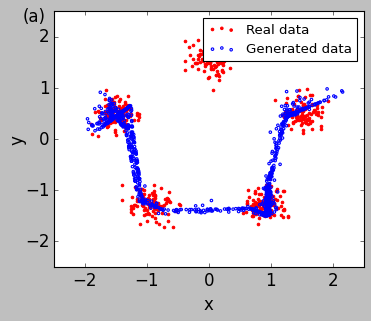

In [12]:
##第4次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
 
# 设置随机数种子
seed = 1234###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

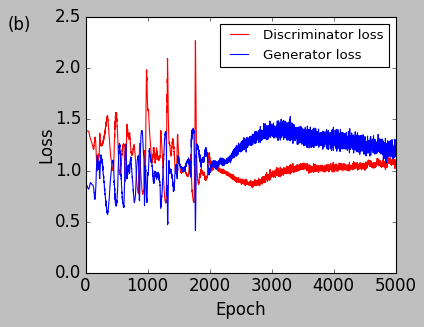

In [13]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.2600
Wasserstein distance (Y-dim): 0.3852
JS Divergence: 0.1201


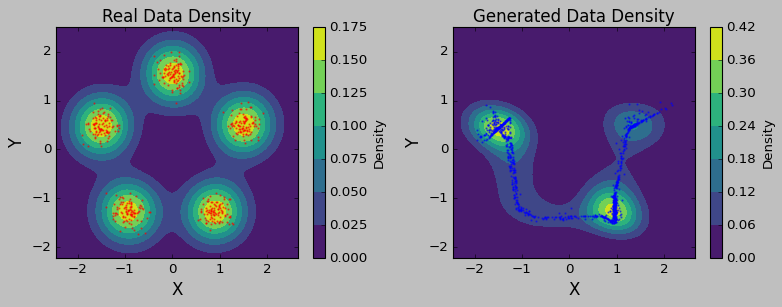

In [14]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

Epoch 0: D Loss: 1.3671, G Loss: 0.6592
Epoch 100: D Loss: 1.0898, G Loss: 0.7874
Epoch 200: D Loss: 0.7634, G Loss: 1.0441
Epoch 300: D Loss: 0.9864, G Loss: 1.2963
Epoch 400: D Loss: 1.0941, G Loss: 1.4287
Epoch 500: D Loss: 1.1087, G Loss: 0.7104
Epoch 600: D Loss: 1.1222, G Loss: 1.3846
Epoch 700: D Loss: 0.8610, G Loss: 1.1333
Epoch 800: D Loss: 1.1643, G Loss: 1.0738
Epoch 900: D Loss: 1.0356, G Loss: 1.0759
Epoch 1000: D Loss: 0.9915, G Loss: 1.1089
Epoch 1100: D Loss: 0.8584, G Loss: 1.2598
Epoch 1200: D Loss: 0.8386, G Loss: 1.2093
Epoch 1300: D Loss: 1.0680, G Loss: 1.1069
Epoch 1400: D Loss: 0.9806, G Loss: 1.1016
Epoch 1500: D Loss: 0.9092, G Loss: 1.1864
Epoch 1600: D Loss: 0.9218, G Loss: 1.2002
Epoch 1700: D Loss: 0.9495, G Loss: 1.2685
Epoch 1800: D Loss: 0.9707, G Loss: 1.2942
Epoch 1900: D Loss: 0.9717, G Loss: 1.3167
Epoch 2000: D Loss: 0.9441, G Loss: 1.3725
Epoch 2100: D Loss: 0.9265, G Loss: 1.4158
Epoch 2200: D Loss: 0.9745, G Loss: 1.3249
Epoch 2300: D Loss: 0.9

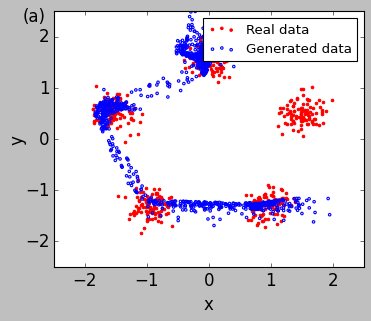

In [9]:
##第5次实验
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
 
# 设置随机数种子
seed = 4321###########连续5次随机种子看看是否成功
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 100 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")
plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig2a.eps', dpi=800)
# 显示图 (a)
plt.show()

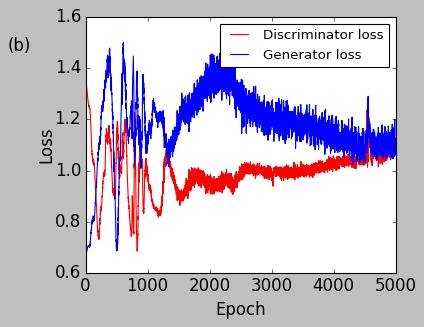

In [10]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.4045
Wasserstein distance (Y-dim): 0.2570
JS Divergence: 0.1254


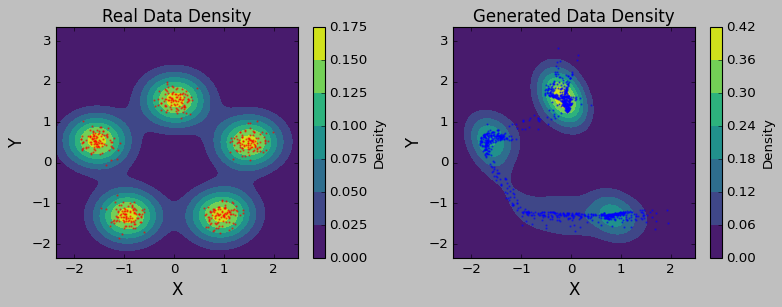

In [11]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

In [ ]:
################针对上述种子利用梯度噪声的实验

Epoch 0: D Loss: 1.3794, G Loss: 0.7441
Epoch 20: D Loss: 1.3691, G Loss: 0.7404
Epoch 40: D Loss: 1.3520, G Loss: 0.7392
Epoch 60: D Loss: 1.3338, G Loss: 0.7387
Epoch 80: D Loss: 1.3087, G Loss: 0.7440
Epoch 100: D Loss: 1.2818, G Loss: 0.7545
Epoch 120: D Loss: 1.2426, G Loss: 0.7714
Epoch 140: D Loss: 1.1968, G Loss: 0.8010
Epoch 160: D Loss: 1.1385, G Loss: 0.8330
Epoch 180: D Loss: 1.0757, G Loss: 0.8801
Epoch 200: D Loss: 1.0109, G Loss: 0.9362
Epoch 220: D Loss: 0.9651, G Loss: 0.9790
Epoch 240: D Loss: 0.9555, G Loss: 1.0034
Epoch 260: D Loss: 1.0042, G Loss: 1.0194
Epoch 280: D Loss: 1.0670, G Loss: 1.0843
Epoch 300: D Loss: 1.0433, G Loss: 1.2183
Epoch 320: D Loss: 0.9979, G Loss: 1.3100
Epoch 340: D Loss: 0.9586, G Loss: 1.3269
Epoch 360: D Loss: 0.9338, G Loss: 1.3025
Epoch 380: D Loss: 0.9109, G Loss: 1.2703
Epoch 400: D Loss: 0.8847, G Loss: 1.2332
Epoch 420: D Loss: 0.8888, G Loss: 1.1951
Epoch 440: D Loss: 0.8546, G Loss: 1.1818
Epoch 460: D Loss: 0.8893, G Loss: 1.104

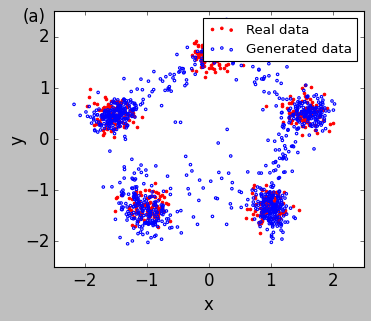

In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.05  # 隐藏层噪声标准差
grad_noise_std = 0.02  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

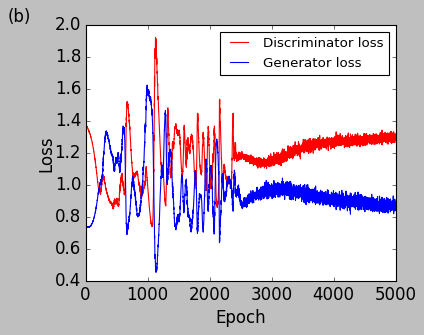

In [27]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig2b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.1139
Wasserstein distance (Y-dim): 0.2092
JS Divergence: 0.0142


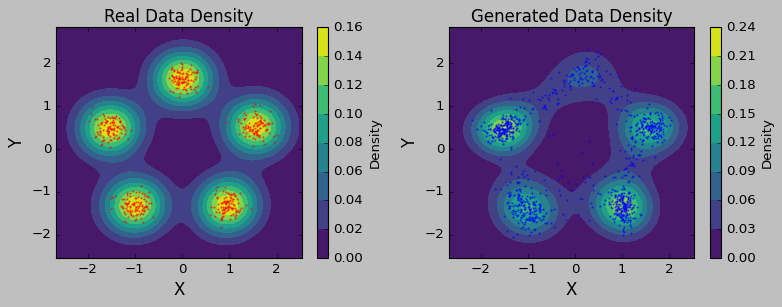

New best JS Divergence: 0.0142 with noise_std=0.1844 and grad_noise_std=0.5102
Best noise_std: 0.1844
Best grad_noise_std: 0.5102
Best JS Divergence: 0.0142


In [33]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

#自适应调整噪声强度
def random_search(generator, discriminator, X_train, z_dim, noise_std, grad_noise_std, 
                  search_iterations=50, batch_size=32, learning_rate=0.0002):
    best_js_divergence = float('inf')
    best_noise_std = noise_std
    best_grad_noise_std = grad_noise_std
    
    for _ in range(search_iterations):
        # 在一定范围内随机选择新的噪声标准差
        noise_std = np.random.uniform(0.01, 1.0)
        grad_noise_std = np.random.uniform(0.01, 1.0)
        
        if js_divergence < best_js_divergence:
            best_js_divergence = js_divergence
            best_noise_std = noise_std
            best_grad_noise_std = grad_noise_std
            print(f"New best JS Divergence: {best_js_divergence:.4f} with noise_std={best_noise_std:.4f} and grad_noise_std={best_grad_noise_std:.4f}")
    
    return best_noise_std, best_grad_noise_std, best_js_divergence
 
best_noise_std, best_grad_noise_std, best_js_divergence = random_search(Generator, Discriminator, X_train, z_dim,noise_std, grad_noise_std)
print(f"Best noise_std: {best_noise_std:.4f}")
print(f"Best grad_noise_std: {best_grad_noise_std:.4f}")
print(f"Best JS Divergence: {best_js_divergence:.4f}")

Epoch 0: D Loss: 1.4055, G Loss: 0.5773
Epoch 20: D Loss: 1.3806, G Loss: 0.6003
Epoch 40: D Loss: 1.3608, G Loss: 0.6199
Epoch 60: D Loss: 1.3428, G Loss: 0.6380
Epoch 80: D Loss: 1.3214, G Loss: 0.6545
Epoch 100: D Loss: 1.2918, G Loss: 0.6739
Epoch 120: D Loss: 1.2534, G Loss: 0.6996
Epoch 140: D Loss: 1.2108, G Loss: 0.7317
Epoch 160: D Loss: 1.1596, G Loss: 0.7720
Epoch 180: D Loss: 1.0991, G Loss: 0.8302
Epoch 200: D Loss: 1.0304, G Loss: 0.9053
Epoch 220: D Loss: 0.9557, G Loss: 0.9872
Epoch 240: D Loss: 0.8828, G Loss: 1.0724
Epoch 260: D Loss: 0.8190, G Loss: 1.1428
Epoch 280: D Loss: 0.7669, G Loss: 1.1900
Epoch 300: D Loss: 0.7201, G Loss: 1.2292
Epoch 320: D Loss: 0.6754, G Loss: 1.2677
Epoch 340: D Loss: 0.6364, G Loss: 1.3178
Epoch 360: D Loss: 0.6150, G Loss: 1.3806
Epoch 380: D Loss: 0.6376, G Loss: 1.4241
Epoch 400: D Loss: 0.6583, G Loss: 1.4821
Epoch 420: D Loss: 0.6975, G Loss: 1.5606
Epoch 440: D Loss: 0.7660, G Loss: 1.4316
Epoch 460: D Loss: 0.9109, G Loss: 1.266

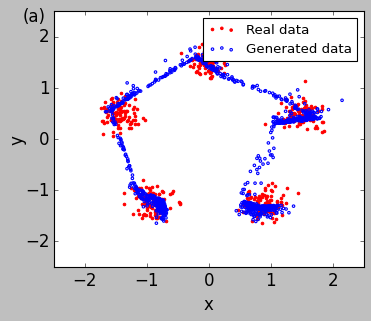

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats

# 设置随机数种子
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0  # 隐藏层噪声标准差
grad_noise_std = 0.02  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

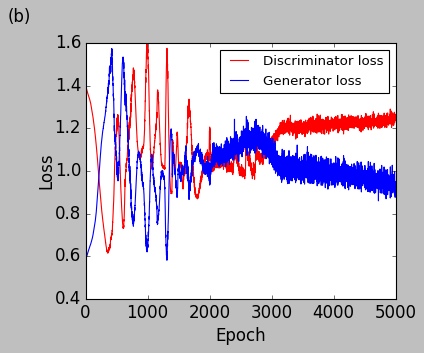

In [36]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.2420
Wasserstein distance (Y-dim): 0.3477
JS Divergence: 0.0382


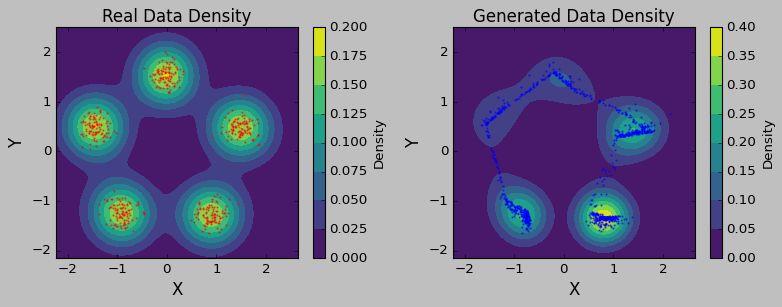

New best JS Divergence: 0.0382 with noise_std=0.1758 and grad_noise_std=0.1135
Best noise_std: 0.1758
Best grad_noise_std: 0.1135
Best JS Divergence: 0.0382


In [37]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

#自适应调整噪声强度
def random_search(generator, discriminator, X_train, z_dim, noise_std, grad_noise_std, 
                  search_iterations=50, batch_size=32, learning_rate=0.0002):
    best_js_divergence = float('inf')
    best_noise_std = noise_std
    best_grad_noise_std = grad_noise_std
    
    for _ in range(search_iterations):
        # 在一定范围内随机选择新的噪声标准差
        noise_std = np.random.uniform(0.01, 1.0)
        grad_noise_std = np.random.uniform(0.01, 1.0)
        
        if js_divergence < best_js_divergence:
            best_js_divergence = js_divergence
            best_noise_std = noise_std
            best_grad_noise_std = grad_noise_std
            print(f"New best JS Divergence: {best_js_divergence:.4f} with noise_std={best_noise_std:.4f} and grad_noise_std={best_grad_noise_std:.4f}")
    
    return best_noise_std, best_grad_noise_std, best_js_divergence
 
best_noise_std, best_grad_noise_std, best_js_divergence = random_search(Generator, Discriminator, X_train, z_dim,noise_std, grad_noise_std)
print(f"Best noise_std: {best_noise_std:.4f}")
print(f"Best grad_noise_std: {best_grad_noise_std:.4f}")
print(f"Best JS Divergence: {best_js_divergence:.4f}")

Epoch 0: D Loss: 1.4048, G Loss: 0.8433
Epoch 20: D Loss: 1.3907, G Loss: 0.8157
Epoch 40: D Loss: 1.3782, G Loss: 0.7904
Epoch 60: D Loss: 1.3667, G Loss: 0.7713
Epoch 80: D Loss: 1.3545, G Loss: 0.7540
Epoch 100: D Loss: 1.3345, G Loss: 0.7389
Epoch 120: D Loss: 1.3095, G Loss: 0.7343
Epoch 140: D Loss: 1.2662, G Loss: 0.7353
Epoch 160: D Loss: 1.2118, G Loss: 0.7533
Epoch 180: D Loss: 1.1329, G Loss: 0.7759
Epoch 200: D Loss: 1.0369, G Loss: 0.8266
Epoch 220: D Loss: 0.9406, G Loss: 0.8773
Epoch 240: D Loss: 0.8627, G Loss: 0.9574
Epoch 260: D Loss: 0.8481, G Loss: 0.9585
Epoch 280: D Loss: 0.8973, G Loss: 1.0087
Epoch 300: D Loss: 0.8758, G Loss: 1.1510
Epoch 320: D Loss: 0.7793, G Loss: 1.3677
Epoch 340: D Loss: 0.6736, G Loss: 1.5353
Epoch 360: D Loss: 0.7018, G Loss: 1.5705
Epoch 380: D Loss: 0.7087, G Loss: 1.7539
Epoch 400: D Loss: 0.6227, G Loss: 1.9005
Epoch 420: D Loss: 0.5850, G Loss: 1.8990
Epoch 440: D Loss: 0.5865, G Loss: 1.7658
Epoch 460: D Loss: 0.6468, G Loss: 1.595

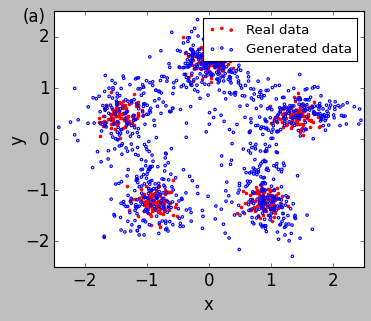

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
# 设置随机数种子
seed = 166
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.1  # 隐藏层噪声标准差
grad_noise_std = 0.015  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

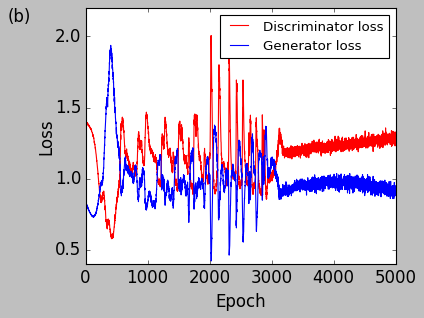

In [39]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.1368
Wasserstein distance (Y-dim): 0.1804
JS Divergence: 0.0236


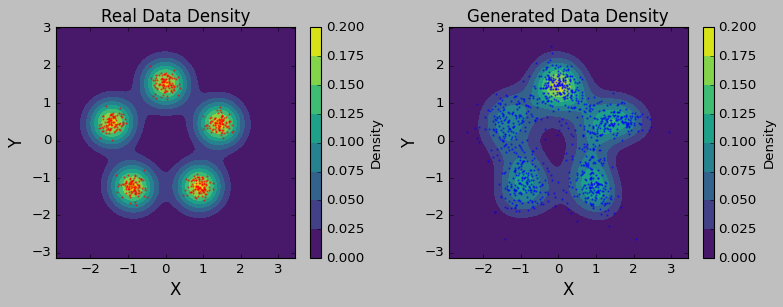

New best JS Divergence: 0.0236 with noise_std=0.9465 and grad_noise_std=0.4775
Best noise_std: 0.9465
Best grad_noise_std: 0.4775
Best JS Divergence: 0.0236


In [40]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

#自适应调整噪声强度
def random_search(generator, discriminator, X_train, z_dim, noise_std, grad_noise_std, 
                  search_iterations=50, batch_size=32, learning_rate=0.0002):
    best_js_divergence = float('inf')
    best_noise_std = noise_std
    best_grad_noise_std = grad_noise_std
    
    for _ in range(search_iterations):
        # 在一定范围内随机选择新的噪声标准差
        noise_std = np.random.uniform(0.01, 1.0)
        grad_noise_std = np.random.uniform(0.01, 1.0)
        
        if js_divergence < best_js_divergence:
            best_js_divergence = js_divergence
            best_noise_std = noise_std
            best_grad_noise_std = grad_noise_std
            print(f"New best JS Divergence: {best_js_divergence:.4f} with noise_std={best_noise_std:.4f} and grad_noise_std={best_grad_noise_std:.4f}")
    
    return best_noise_std, best_grad_noise_std, best_js_divergence
 
best_noise_std, best_grad_noise_std, best_js_divergence = random_search(Generator, Discriminator, X_train, z_dim,noise_std, grad_noise_std)
print(f"Best noise_std: {best_noise_std:.4f}")
print(f"Best grad_noise_std: {best_grad_noise_std:.4f}")
print(f"Best JS Divergence: {best_js_divergence:.4f}")

Epoch 0: D Loss: 1.4180, G Loss: 0.8866
Epoch 20: D Loss: 1.4038, G Loss: 0.8633
Epoch 40: D Loss: 1.3926, G Loss: 0.8373
Epoch 60: D Loss: 1.3899, G Loss: 0.8201
Epoch 80: D Loss: 1.3705, G Loss: 0.8047
Epoch 100: D Loss: 1.3614, G Loss: 0.7900
Epoch 120: D Loss: 1.3479, G Loss: 0.7816
Epoch 140: D Loss: 1.3358, G Loss: 0.7772
Epoch 160: D Loss: 1.3215, G Loss: 0.7773
Epoch 180: D Loss: 1.2996, G Loss: 0.7807
Epoch 200: D Loss: 1.2798, G Loss: 0.7932
Epoch 220: D Loss: 1.2593, G Loss: 0.8045
Epoch 240: D Loss: 1.2392, G Loss: 0.8231
Epoch 260: D Loss: 1.2011, G Loss: 0.8709
Epoch 280: D Loss: 1.1424, G Loss: 0.9629
Epoch 300: D Loss: 1.0573, G Loss: 1.0720
Epoch 320: D Loss: 0.9812, G Loss: 1.1359
Epoch 340: D Loss: 0.9349, G Loss: 1.1476
Epoch 360: D Loss: 0.9110, G Loss: 1.1260
Epoch 380: D Loss: 0.8861, G Loss: 1.1066
Epoch 400: D Loss: 0.8573, G Loss: 1.0917
Epoch 420: D Loss: 0.8205, G Loss: 1.1054
Epoch 440: D Loss: 0.8119, G Loss: 1.1088
Epoch 460: D Loss: 0.8152, G Loss: 1.094

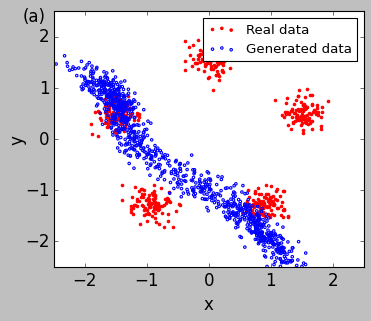

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
# 设置随机数种子
seed = 1234
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.1  # 隐藏层噪声标准差
grad_noise_std = 0.015  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

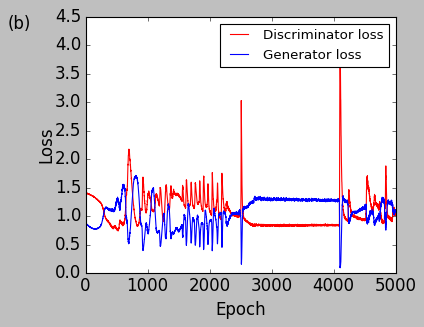

In [42]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.4053
Wasserstein distance (Y-dim): 0.5621
JS Divergence: 0.4011


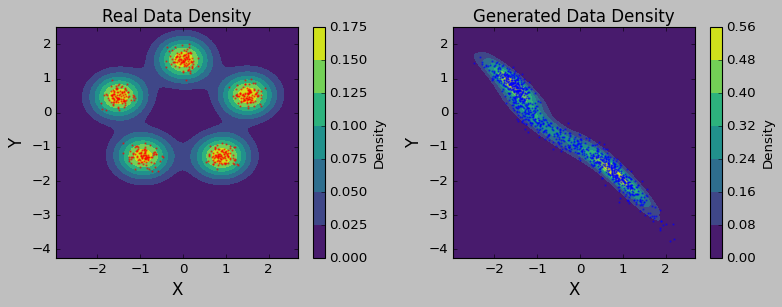

New best JS Divergence: 0.4011 with noise_std=0.4067 and grad_noise_std=0.4090
Best noise_std: 0.4067
Best grad_noise_std: 0.4090
Best JS Divergence: 0.4011


In [43]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

#自适应调整噪声强度
def random_search(generator, discriminator, X_train, z_dim, noise_std, grad_noise_std, 
                  search_iterations=50, batch_size=32, learning_rate=0.0002):
    best_js_divergence = float('inf')
    best_noise_std = noise_std
    best_grad_noise_std = grad_noise_std
    
    for _ in range(search_iterations):
        # 在一定范围内随机选择新的噪声标准差
        noise_std = np.random.uniform(0.01, 1.0)
        grad_noise_std = np.random.uniform(0.01, 1.0)
        
        if js_divergence < best_js_divergence:
            best_js_divergence = js_divergence
            best_noise_std = noise_std
            best_grad_noise_std = grad_noise_std
            print(f"New best JS Divergence: {best_js_divergence:.4f} with noise_std={best_noise_std:.4f} and grad_noise_std={best_grad_noise_std:.4f}")
    
    return best_noise_std, best_grad_noise_std, best_js_divergence
 
best_noise_std, best_grad_noise_std, best_js_divergence = random_search(Generator, Discriminator, X_train, z_dim,noise_std, grad_noise_std)
print(f"Best noise_std: {best_noise_std:.4f}")
print(f"Best grad_noise_std: {best_grad_noise_std:.4f}")
print(f"Best JS Divergence: {best_js_divergence:.4f}")

Epoch 0: D Loss: 1.3675, G Loss: 0.6588
Epoch 20: D Loss: 1.3448, G Loss: 0.6777
Epoch 40: D Loss: 1.3185, G Loss: 0.6928
Epoch 60: D Loss: 1.2942, G Loss: 0.7067
Epoch 80: D Loss: 1.2699, G Loss: 0.7173
Epoch 100: D Loss: 1.2412, G Loss: 0.7298
Epoch 120: D Loss: 1.2054, G Loss: 0.7447
Epoch 140: D Loss: 1.1594, G Loss: 0.7641
Epoch 160: D Loss: 1.1037, G Loss: 0.7872
Epoch 180: D Loss: 1.0466, G Loss: 0.8124
Epoch 200: D Loss: 0.9839, G Loss: 0.8450
Epoch 220: D Loss: 0.9198, G Loss: 0.8908
Epoch 240: D Loss: 0.8644, G Loss: 0.9384
Epoch 260: D Loss: 0.8050, G Loss: 1.0029
Epoch 280: D Loss: 0.7484, G Loss: 1.0615
Epoch 300: D Loss: 0.6749, G Loss: 1.1550
Epoch 320: D Loss: 0.6142, G Loss: 1.2419
Epoch 340: D Loss: 0.6470, G Loss: 1.2615
Epoch 360: D Loss: 0.7071, G Loss: 1.3147
Epoch 380: D Loss: 0.6922, G Loss: 1.4502
Epoch 400: D Loss: 0.6466, G Loss: 1.4875
Epoch 420: D Loss: 0.6039, G Loss: 1.4779
Epoch 440: D Loss: 0.5682, G Loss: 1.4923
Epoch 460: D Loss: 0.6023, G Loss: 1.378

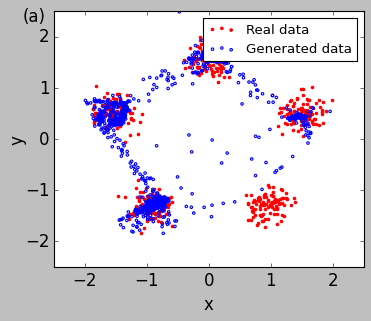

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.metrics import pairwise_distances
from scipy.stats import wasserstein_distance
from scipy import stats
# 设置随机数种子
seed = 4321
torch.manual_seed(seed)
np.random.seed(seed)

def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)

        self.relu = nn.ReLU()
        self.noise_std = noise_std

    def forward(self, z_input):
        # 添加噪声到输入
        z_input = z_input + torch.randn_like(z_input) * self.noise_std
        g_y1 = self.relu(self.fc1(z_input))
        g_y1 = g_y1 + torch.randn_like(g_y1) * self.noise_std  # 添加噪声到隐藏层
        g_y2 = self.relu(self.fc2(g_y1))
        g_y2 = g_y2 + torch.randn_like(g_y2) * self.noise_std  # 添加噪声到隐藏层
        g_y3 = self.relu(self.fc3(g_y2))
        g_y3 = g_y3 + torch.randn_like(g_y3) * self.noise_std  # 添加噪声到隐藏层
        g_y4 = self.fc4(g_y3)
        return g_y4

class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std=0):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.noise_std = noise_std

    def forward(self, x_input):
        # 添加噪声到输入
        x_input = x_input + torch.randn_like(x_input) * self.noise_std
        d_y1 = self.relu(self.fc1(x_input))
        d_y1 = d_y1 + torch.randn_like(d_y1) * self.noise_std  # 添加噪声到隐藏层
        d_y2 = self.relu(self.fc2(d_y1))
        d_y2 = d_y2 + torch.randn_like(d_y2) * self.noise_std  # 添加噪声到隐藏层
        d_y3 = self.relu(self.fc3(d_y2))
        d_y3 = d_y3 + torch.randn_like(d_y3) * self.noise_std  # 添加噪声到隐藏层
        d_y4 = self.fc4(d_y3)
        output = self.sigmoid(d_y4)
        return output, d_y4

# 自定义损失函数
def discriminator_loss(d_real, d_fake):
    # 判别器希望 d_real 接近 1，d_fake 接近 0
    d_loss_real = -torch.mean(torch.log(d_real + 1e-8))  # 添加一个小常数避免 log(0)
    d_loss_fake = -torch.mean(torch.log(1 - d_fake + 1e-8))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    # 生成器希望 d_fake 接近 1
    return -torch.mean(torch.log(d_fake + 1e-8))

# 梯度噪声注入函数
def add_gradient_noise(parameters, grad_noise_std):
    for param in parameters:
        if param.grad is not None:
            noise = torch.randn_like(param.grad) * grad_noise_std
            param.grad += noise

# Hyperparameters
nb_neurons_h1 = 16
nb_neurons_h2 = 16
nb_neurons_h3 = 16
learning_rate = 5e-5
batch_size = 32
noise_std = 0.005  # 隐藏层噪声标准差
grad_noise_std = 0.02  # 梯度噪声标准差

z_dim = 2
x_dim = 2
img_dim = 2

# Initialize models
generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)
discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, noise_std)

# Optimizers
g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

epochs = 5000
X_train = genGauss(100, 5, 0.5)
X_train = torch.Tensor(X_train)
indices = torch.randperm(X_train.size(0))  # 获取打乱后的索引
X_train = X_train[indices]  # 根据新的索引重新排序 X_train

epoch_discriminator_loss = []
epoch_generator_loss = []

# Training loop
for epoch in range(epochs):
    batch_discriminator_loss = []
    batch_generator_loss = []
    nb_batches = int(X_train.shape[0] / batch_size)

    for i in range(nb_batches):
        image_batch = X_train[i * batch_size:(i + 1) * batch_size]

        # Train discriminator
        z_input = torch.randn(batch_size, z_dim)
        fake_img = generator(z_input)

        # Discriminator loss on real images
        d_real, _ = discriminator(image_batch)
        d_fake, _ = discriminator(fake_img.detach())

        # 使用自定义的判别器损失函数
        d_loss = discriminator_loss(d_real, d_fake)

        d_optimizer.zero_grad()
        d_loss.backward()
        add_gradient_noise(discriminator.parameters(), grad_noise_std)  # 梯度噪声注入
        d_optimizer.step()

        # Train generator
        d_fake, _ = discriminator(fake_img)

        # 使用自定义的生成器损失函数
        g_loss = generator_loss(d_fake)

        g_optimizer.zero_grad()
        g_loss.backward()
        add_gradient_noise(generator.parameters(), grad_noise_std)  # 梯度噪声注入
        g_optimizer.step()

        # Track losses
        batch_discriminator_loss.append(d_loss.item())
        batch_generator_loss.append(g_loss.item())

    epoch_discriminator_loss.append(np.mean(batch_discriminator_loss))
    epoch_generator_loss.append(np.mean(batch_generator_loss))

    # Print losses every 20 epochs
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: D Loss: {np.mean(batch_discriminator_loss):.4f}, G Loss: {np.mean(batch_generator_loss):.4f}")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.style.use(['classic'])
# 生成 GAN 的输出数据（假设 samples 是 GAN 生成的样本）
samples = generator(torch.randn(1000, z_dim)).detach().numpy()

# 图 (a): 真实数据 vs 生成数据
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('x', fontsize=15)
ax.set_ylabel('y', fontsize=15, labelpad=-1)
ax.set_xlim(-2.5, 2.5)  # 设置 x 轴范围
ax.set_ylim(-2.5, 2.5)  # 设置 y 轴范围

# 绘制真实数据（红色星号）
ax.scatter(X_train[:, 0], X_train[:, 1], color="red", label='Real data', marker='.')
# 绘制生成数据（蓝色点）
ax.scatter(samples[:, 0], samples[:, 1], color="blue", label='Generated data', marker='o', facecolors='none', edgecolors='blue',s=5)
ax.legend(loc='upper right', fontsize=12)
ax.text(-3, 2.3, '(a)', fontsize=15)  # 标记 (a)
#fig.savefig('D:/GAN2024/Fig1a.eps', dpi=800)
# 显示图 (a)
plt.show()

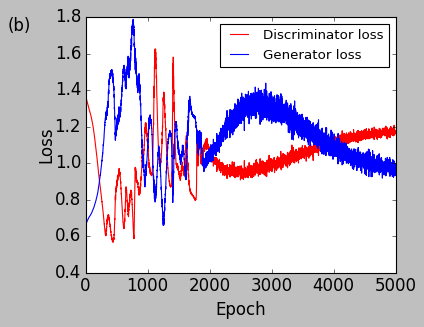

In [45]:
# 图 (b): 损失曲线
fig, ax = plt.subplots(figsize=(5, 4))
plt.cla()
ax.tick_params(labelsize=15)
ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Loss', fontsize=15, labelpad=-1)

# 绘制判别器损失曲线
ax.plot(epoch_discriminator_loss, color='red', label='Discriminator loss')
# 绘制生成器损失曲线
ax.plot(epoch_generator_loss, color='blue', label='Generator loss')
ax.legend(loc='upper right', fontsize=12)
ax.text(-1250, max(epoch_discriminator_loss) + 0.1, '(b)', fontsize=15)  # 标记 (b)
#fig.savefig('D:/GAN2024/Fig1b.eps', dpi=800)
# 显示图 (b)
plt.show()

Wasserstein distance (X-dim): 0.6772
Wasserstein distance (Y-dim): 0.1553
JS Divergence: 0.1033


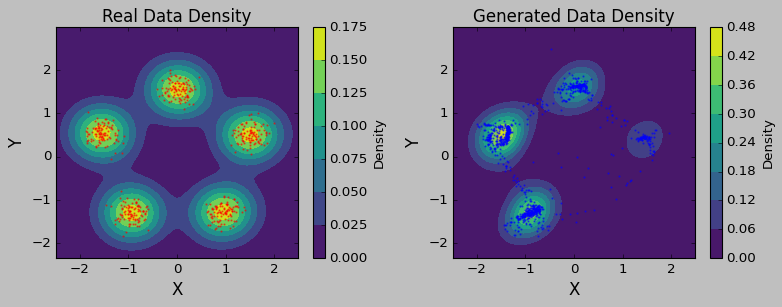

New best JS Divergence: 0.1033 with noise_std=0.3145 and grad_noise_std=0.9997
Best noise_std: 0.3145
Best grad_noise_std: 0.9997
Best JS Divergence: 0.1033


In [46]:
# 确保 X_train 和 samples 是numpy数组
X_train_np = X_train.detach().numpy()
#samples_np = samples.detach().numpy()
samples_np=samples
# 1. 计算Wasserstein距离
w_dist_x = wasserstein_distance(X_train_np[:, 0], samples_np[:, 0])
w_dist_y = wasserstein_distance(X_train_np[:, 1], samples_np[:, 1])
print(f"Wasserstein distance (X-dim): {w_dist_x:.4f}")
print(f"Wasserstein distance (Y-dim): {w_dist_y:.4f}")
# 2. 计算JS散度
# 首先定义高斯核密度估计（KDE）函数
def gaussian_kde(data):
    return stats.gaussian_kde(data.T)
# 计算真实数据和生成数据的KDE
real_kernel = gaussian_kde(X_train_np)
gen_kernel = gaussian_kde(samples_np)
# 定义网格用于绘制KDE
x_min, x_max = min(X_train_np[:, 0].min(), samples_np[:, 0].min()) - 0.5, max(X_train_np[:, 0].max(), samples_np[:, 0].max()) + 0.5
y_min, y_max = min(X_train_np[:, 1].min(), samples_np[:, 1].min()) - 0.5, max(X_train_np[:, 1].max(), samples_np[:, 1].max()) + 0.5
xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])
# 计算真实数据和生成数据的密度
real_density = np.reshape(real_kernel(positions), xx.shape)
gen_density = np.reshape(gen_kernel(positions), xx.shape)
# 近似计算JS散度
def js_divergence_approx(p, q):
    # Normalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    # Renormalize
    p = p / np.sum(p)
    q = q / np.sum(q)
    # Calculate M = (P+Q)/2
    m = (p + q) / 2
    # Calculate JS divergence
    js = 0.5 * np.sum(p * np.log(p / m)) + 0.5 * np.sum(q * np.log(q / m))
    return js
# 计算JS散度
js_divergence = js_divergence_approx(real_density, gen_density)
print(f"JS Divergence: {js_divergence:.4f}")
# 可视化KDE
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['figure.dpi'] = 800
plt.rcParams['axes.unicode_minus'] = False
plt.style.use(['classic'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
im1 = axes[0].contourf(xx, yy, real_density, cmap='viridis')
axes[0].set_title('Real Data Density', fontsize=15)
axes[0].set_xlabel('X', fontsize=15)
axes[0].set_ylabel('Y', fontsize=15)
axes[0].scatter(X_train_np[:, 0], X_train_np[:, 1], s=1, color='red', alpha=0.5)
axes[0].tick_params(labelsize=12)

im2 = axes[1].contourf(xx, yy, gen_density, cmap='viridis')
axes[1].set_title('Generated Data Density', fontsize=15)
axes[1].set_xlabel('X', fontsize=15)
axes[1].set_ylabel('Y', fontsize=15)
axes[1].scatter(samples_np[:, 0], samples_np[:, 1], s=1, color='blue', alpha=0.5)
axes[1].tick_params(labelsize=12)
 
fig.colorbar(im1, ax=axes[0], label='Density')
fig.colorbar(im2, ax=axes[1], label='Density')
 
plt.tight_layout()
#plt.savefig('D:/GAN2024/density_heatmap.eps', dpi=800)
plt.show()

#自适应调整噪声强度
def random_search(generator, discriminator, X_train, z_dim, noise_std, grad_noise_std, 
                  search_iterations=50, batch_size=32, learning_rate=0.0002):
    best_js_divergence = float('inf')
    best_noise_std = noise_std
    best_grad_noise_std = grad_noise_std
    
    for _ in range(search_iterations):
        # 在一定范围内随机选择新的噪声标准差
        noise_std = np.random.uniform(0.01, 1.0)
        grad_noise_std = np.random.uniform(0.01, 1.0)
        
        if js_divergence < best_js_divergence:
            best_js_divergence = js_divergence
            best_noise_std = noise_std
            best_grad_noise_std = grad_noise_std
            print(f"New best JS Divergence: {best_js_divergence:.4f} with noise_std={best_noise_std:.4f} and grad_noise_std={best_grad_noise_std:.4f}")
    
    return best_noise_std, best_grad_noise_std, best_js_divergence
 
best_noise_std, best_grad_noise_std, best_js_divergence = random_search(Generator, Discriminator, X_train, z_dim,noise_std, grad_noise_std)
print(f"Best noise_std: {best_noise_std:.4f}")
print(f"Best grad_noise_std: {best_grad_noise_std:.4f}")
print(f"Best JS Divergence: {best_js_divergence:.4f}")

In [ ]:
#########end，下面进行激活函数更换实验